In [43]:
import sys
import os
sys.path.append(os.path.abspath("../.."))
from quantile_forest import RandomForestQuantileRegressor
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
from tinyconformal.regressor import ConformalizedQuantileRegressor
from tinyconformal.regressor import ExactnessBound
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor


In [44]:
from pathlib import Path
EXAMPLES_DIR = Path.cwd().parent
if str(EXAMPLES_DIR) not in sys.path:
    sys.path.insert(0, str(EXAMPLES_DIR))
from utils.plot_utils import plot_prediction_intervals
from tinyconformal.utils.mqr import MultiQuantileRegressor

In [45]:
data = fetch_california_housing(as_frame=True)
X, y = data.data, data.target


In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_calib, y_train, y_calib = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

In [47]:
coverage = 0.80
alpha = 1 - coverage
quantiles = [alpha/2, 1 - alpha/2]

In [48]:
rf = RandomForestQuantileRegressor(random_state=42, default_quantiles=quantiles, n_jobs=-1, oob_score=True, max_depth=int(np.ceil(np.log2(len(X_train)) - 1)))
rf.fit(X_train, y_train)

,n_estimators,100
,default_quantiles,"[0.09999999999999998, 0.9]"
,criterion,'squared_error'
,max_depth,13
,min_samples_split,2
,min_samples_leaf,1
,max_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0


In [49]:
tilde_beta, beta = ExactnessBound.estimate_cqr_bound(rf, X_train, y_train, p=0.95)

In [50]:
reg = ConformalizedQuantileRegressor(
    rf,
    alpha=alpha,
)
reg.unlabeled_fit(X_train, tilde_beta, beta)

,learner,RandomForestQ...ndom_state=42)
,alpha,0.19999999999999996
,n_estimators,100
,default_quantiles,"[0.09999999999999998, 0.9]"
,criterion,'squared_error'
,max_depth,13
,min_samples_split,2
,min_samples_leaf,1
,max_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0


In [51]:
y_pred_intervals = reg.predict_interval(X_test, alpha=0.2)
y_pred = reg.predict(X_test)

In [52]:
reg.evaluate(X_test, y_test, alpha=0.2)

{'total': 4128,
 'alpha': 0.2,
 'beta': 0.05,
 'coverage_rate': np.float64(0.949),
 'interval_width_mean': np.float64(1.666),
 'mwis': np.float64(1.885),
 'mae': np.float64(0.344),
 'mbe': np.float64(-0.09),
 'mse': np.float64(0.292)}

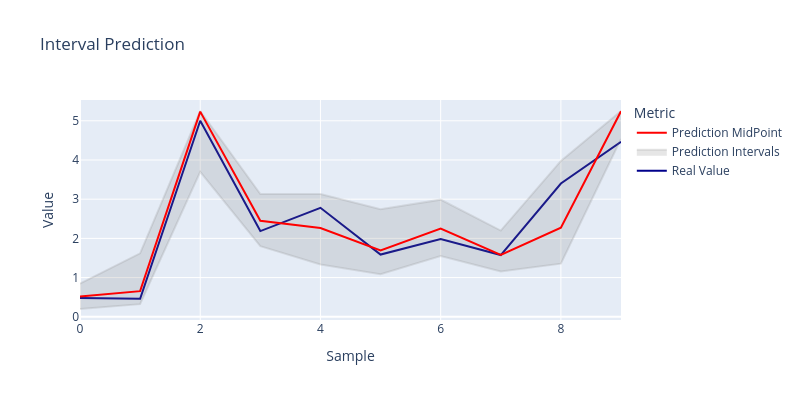

In [53]:
plot_prediction_intervals(y_pred_intervals[:10], y_pred[:10], y_test[:10], fig_type="png")

# MultiQuantileRegressor - HistGradientBoostingRegressor

In [54]:
mq_model = MultiQuantileRegressor(
        base_estimator=HistGradientBoostingRegressor(loss="quantile", random_state=42),
        quantiles=(0.05, 0.5, 0.95),
    )
mq_model.fit(X_train, y_train)

,base_estimator,HistGradientB...ndom_state=42)
,quantiles,"(0.05, ...)"
,loss,'quantile'
,quantile,None
,learning_rate,0.1
,max_iter,100
,max_leaf_nodes,31
,max_depth,None
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0


In [55]:
tilde_beta, beta = ExactnessBound.estimate_cqr_bound(mq_model, X_train, y_train, p=0.90)

In [56]:
cqr = ConformalizedQuantileRegressor(learner=mq_model, alpha=0.1)
cqr.unlabeled_fit(X_train, tilde_beta, beta)

,learner,"MultiQuantile...5, 0.5, 0.95))"
,alpha,0.1
,loss,'quantile'
,quantile,None
,learning_rate,0.1
,max_iter,100
,max_leaf_nodes,31
,max_depth,None
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0


In [57]:
y_pred_intervals = cqr.predict_interval(X_test)
y_pred = cqr.predict(X_test)

In [58]:
cqr.evaluate(X_test, y_test)

{'total': 4128,
 'alpha': 0.1,
 'beta': 0.1,
 'coverage_rate': np.float64(0.896),
 'interval_width_mean': np.float64(1.491),
 'mwis': np.float64(2.079),
 'mae': np.float64(0.323),
 'mbe': np.float64(-0.064),
 'mse': np.float64(0.262)}

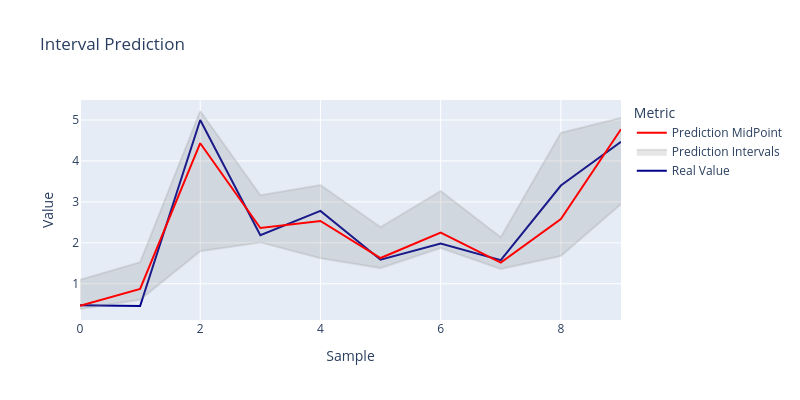

In [59]:
plot_prediction_intervals(y_pred_intervals[:10], y_pred[:10], y_test[:10], fig_type="png")